### Import packages

In [90]:
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import plot_tree
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, fbeta_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import to_graphviz
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.feature_selection import RFECV,SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, roc_auc_score
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# BNPL1 - Full data

### Data preprocessing

1. LOAD DATA

In [7]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_15334/2634253260.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [9]:
# check nas
pd.set_option('display.max_rows', None)

data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year']).loc[-data['BNPL1'].isna()].isna().sum()

weight          0
BNPL3       41725
EF3_a           0
EF3_b           0
EF3_c           0
EF3_d           0
EF3_e           0
EF3_f           0
EF3_g           0
EF3_h           0
I20             0
ppfs0596    15375
ppeducat        0
ppage           0
ppagecat        0
ppethm          0
ppgender        0
ppinc7          0
ppemploy        0
ppmarit5        0
pphhsize        0
ppkid017        0
ppfs1482     7202
SL6         40929
B3              0
A6              0
C4A          6901
EF1             0
L0C         36413
I41_c       18158
I41_e       36413
A1_a        30689
A1_b        30689
A1_c        30689
X12_a       41111
X12_b       41111
X12_c       41111
X12_d       41111
X12_e       41111
X12_f       41111
X12_g       41111
EF5C        23541
dtype: int64

comment: leaving out columns SL6, I41_c, I41_e, A1_a, A1_b, A1_c, X12_a, X12_b, X12_c, X12_d, X12_e, X12_f, X12_g, EF5C from full data regression. include these columns for 2024 year regression.

Drop nas

In [15]:
# drop columns
data_cleaned = data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])
data_cleaned.loc[-data_cleaned['BNPL1'].isna()].isna().sum()

# independent variables
X = data_cleaned.drop(columns=['BNPL1','weight'])
# target variable
y = data_cleaned['BNPL1']

# weights
weights = data_cleaned['weight']


Check X columns

In [29]:
pd.DataFrame([(c,X[c].unique()) for c in X.columns], columns=['column', 'values'])

,column,values
0,EF3_a,"[Yes, No]"
1,EF3_b,"[No, Yes]"
2,EF3_c,"[No, Yes]"
3,EF3_d,"[No, Yes]"
4,EF3_e,"[No, Yes]"
5,EF3_f,"[No, Yes]"
6,EF3_g,"[No, Yes]"
7,EF3_h,"[No, Yes]"
8,I20,"[The same as your income, More than your incom..."
9,ppfs0596,"[$50,000 - $99,999, Not sure, Under $50,000, n..."


Data transformation

In [ ]:
# to ordinal
cols1 = ['pphhsize','ppage','ppkid017']
for c in cols1:
  X[c] = X[c].astype(float)

# to categorical
cols2 = [c for c in X.columns if c not in cols1]
for c in cols2:
  X[c] = X[c].astype("category")

y = y.map({'No': 0, 'Yes': 1})

### XGBoost

Modeling

In [129]:
xgb_results = []
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }

# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3,5],
    'min_child_weight': [5, 10],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0.1, 0.5, 1]
}

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test_aug["weight"].values
X_test = X_test_aug.drop(columns=["weight"])

scoring = {
    'f1_class1': make_scorer(f1_score, pos_label=1),
    'recall_class1': make_scorer(recall_score, pos_label=1),
    'precision_class1': make_scorer(precision_score, pos_label=1)
}

# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="auc",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='roc_auc',   # AUC metric
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)

# Prediction
y_pred = grid_search.predict(X_test)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=200, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=

Show results

Best Parmaters: {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.8}
AUC: 0.8615881457783854


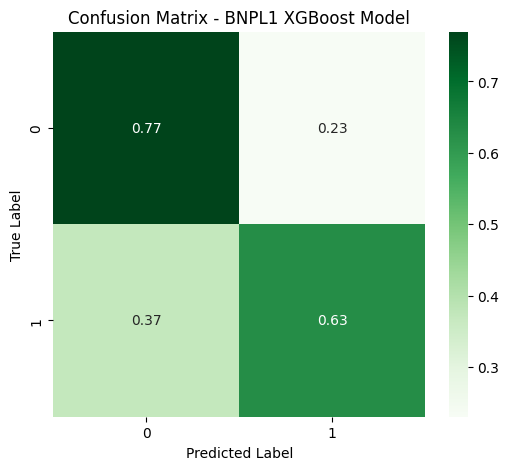

In [130]:
# save scores
auc_score = grid_search.best_score_
best_parameters = grid_search.best_params_
cm = confusion_matrix(y_test, y_pred, normalize='true')

# auc
print('Best Parmaters:', best_parameters)
print('AUC:', auc_score)
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL1 XGBoost Model")
plt.show()


### Display tree

/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


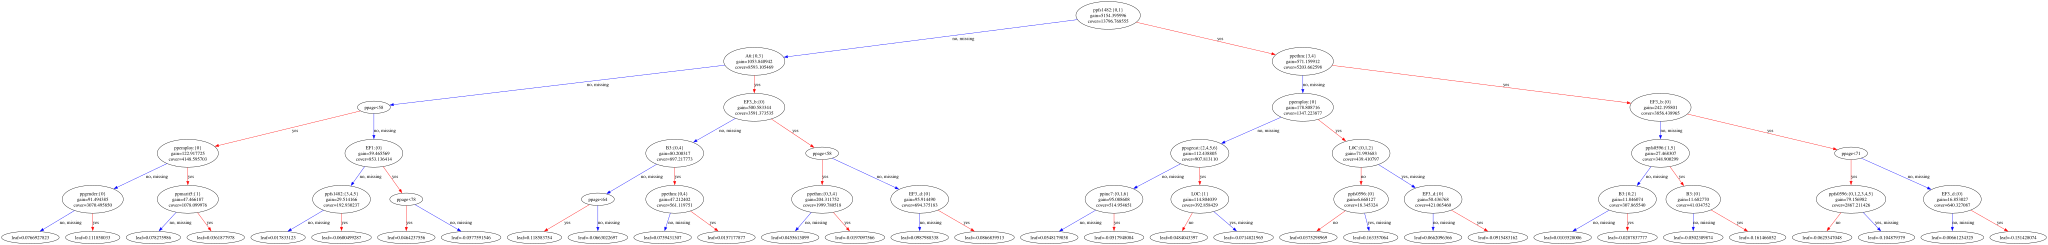

In [131]:
# best model
best_model = grid_search.best_estimator_

graph = to_graphviz(best_model, num_trees=0)
graph

## BNPL3 - full data

### Data preprocessing

In [146]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_11632/2634253260.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [147]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL3']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data[c] = data[c].map(map_cols1)

In [148]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data[c], prefix=c).astype(int)

data = pd.concat([data, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [149]:
# multi-class to ordinal
cols3 = ['X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

map_cols3 = ({
    'Not a concern': 0,
    'Minor concern': 1,
    'Major concern': 2
})

for c in cols3:
  data[c] = data[c].map(map_cols3)

In [150]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017",'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

scaler = StandardScaler()

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [151]:
data = data.loc[-data['BNPL3'].isna()]

In [152]:
# check nas
pd.set_option('display.max_rows', None)

data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                   # below columns are transformed to OHE columns. need to drop original ones
                       'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']).loc[-data['BNPL3'].isna()].isna().sum()

weight                                                                          0
BNPL3                                                                           0
EF3_a                                                                           0
EF3_b                                                                           0
EF3_c                                                                           0
EF3_d                                                                           0
EF3_e                                                                           0
EF3_f                                                                           0
EF3_g                                                                           0
EF3_h                                                                           0
ppage                                                                           0
ppgender                                                                        0
pphhsize        

comment: leaving out columns SL6, I41_c, I41_e, A1_a, A1_b, A1_c, X12_a, X12_b, X12_c, X12_d, X12_e, X12_f, X12_g, EF5C from full data regression. include these columns for 2024 year regression.

In [153]:
# drop columns
data_cleaned = data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])


# independent variables
X = data_cleaned.drop(columns=['BNPL3','weight'])
# target variable
y = data_cleaned['BNPL3']

# weights
weights = data_cleaned['weight']


### Feature selection

In [154]:
from imblearn.pipeline import Pipeline

BNPL3_svc_model = LinearSVC(max_iter=2000)

rfecv = RFECV(
    estimator=BNPL3_svc_model,
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="f1"
)

# pipeline: resampling happens BEFORE RFECV in each fold
pipeline = Pipeline(steps=[
    ("resample", RandomOverSampler(random_state=42)),
    ("feature_selection", rfecv)
])

# Fit pipeline
pipeline.fit(X, y)

,steps,"[('resample', ...), ('feature_selection', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,shrinkage,None
,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearSVC(max_iter=2000)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)


In [156]:
# get selected features
rfecv = pipeline.named_steps["feature_selection"]
mask = rfecv.support_
selected_features_BNPL3 = X.columns[mask]
print(selected_features_BNPL3)

Index(['EF3_c', 'EF3_d', 'EF3_e', 'EF3_f', 'EF3_h', 'ppkid017',
       'I20_Less than your income', 'ppfs0596_$1,000,000 or more',
       'ppfs0596_$250,000 - $499,999', 'ppfs0596_$500,000 - $999,999',
       'ppfs0596_Under $50,000', 'ppeducat_No high school diploma or GED',
       'ppethm_2+ Races, Non-Hispanic', 'ppethm_Other, Non-Hispanic',
       'ppethm_White, Non-Hispanic', 'ppinc7_$10,000 to $24,999',
       'ppinc7_$100,000 to $149,999', 'ppinc7_$150,000 or more',
       'ppinc7_$75,000 to $99,999', 'ppinc7_Less than $10,000',
       'ppmarit5_Divorced', 'ppmarit5_Never married', 'ppagecat_18-24',
       'ppagecat_45-54', 'ppagecat_65-74', 'ppagecat_75+',
       'ppfs1482_Excellent', 'ppfs1482_Fair', 'ppfs1482_Poor',
       'ppfs1482_Very poor', 'B3_Much worse off', 'A6_Not confident',
       'A6_Very confident', 'C4A_Most or all of the time',
       'C4A_Never carried an unpaid balance (always pay in full)', 'C4A_Once',
       'C4A_Some of the time', 'L0C_1', 'L0C_2', 'L0C_3'

### SVC Model

Modeling

In [157]:
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug = X_aug[selected_features_BNPL3]
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
y_true_all = []
y_pred_all = []
weights_all = []
f1_scores = []

for train_idx, val_idx in skf.split(X_train_aug, y_train):

    X_tr = X_train_aug.iloc[train_idx].copy()
    X_val = X_train_aug.iloc[val_idx].copy()

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Resample ONLY training fold
    ros = RandomOverSampler(random_state=42)
    X_tr_res, y_tr_res = ros.fit_resample(X_tr, y_tr)

    # Extract weights
    w_tr_res = X_tr_res["weight"].values
    X_tr_res = X_tr_res.drop(columns=["weight"])

    w_val = X_val["weight"].values
    X_val = X_val.drop(columns=["weight"])

    # Train model
    model = LinearSVC(
        C=0.1,
        penalty='l1',
        dual=False,
        max_iter=5000
    )

    model.fit(X_tr_res, y_tr_res, sample_weight=w_tr_res)
    y_pred = model.predict(X_val)

    # ---------------------------
    # 4. Evaluation
    # ---------------------------

    # AUC
    y_scores = model.decision_function(X_val)
    auc = roc_auc_score(y_val, y_pred)
    auc_scores.append(auc)

    # F1
    f1 = f1_score(y_val, y_pred)
    f1_scores.append(f1)

    # Confusion matrix metrics
    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred)
    weights_all.extend(w_val)


Evaluation results

CV AUC: 0.7294146480045225
F1 Score: 0.48647578339066805
Confusion Matrix: [[0.70346272 0.29653728]
 [0.25238914 0.74761086]]


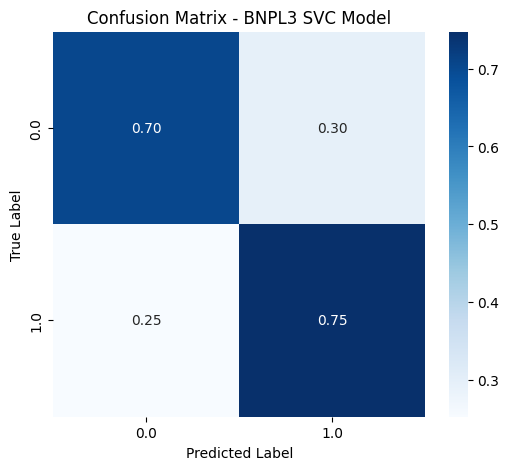

In [159]:
# ---------------------------
# 5. Model results
# ---------------------------

print("CV AUC:", np.mean(auc_scores))
print("F1 Score:", np.mean(f1_scores))

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    sample_weight=weights_all,
    normalize='true'
)

print("Confusion Matrix:", cm)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL3 SVC Model")
plt.show()


## BNPL1 - 2024 data

### Data pre-processing

In [190]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]
data_2024 = data.loc[data['year']==2024]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_11632/2448053278.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [191]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL1']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data_2024[c] = data_2024[c].map(map_cols1)

In [192]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data_2024[c], prefix=c).astype(int)

data_2024 = pd.concat([data_2024, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [193]:
# multi-class to ordinal
cols3 = ['X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

map_cols3 = ({
    'Not a concern': 0,
    'Minor concern': 1,
    'Major concern': 2
})

for c in cols3:
  data_2024[c] = data_2024[c].map(map_cols3)

In [194]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017",'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

scaler = StandardScaler()

data_2024[numeric_cols] = scaler.fit_transform(data_2024[numeric_cols])

In [195]:
data_2024 = data_2024.loc[-data_2024['BNPL1'].isna()]

In [196]:
# drop columns
data2024_cleaned = data_2024.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                      'I41_c','I41_e', 'SL6', 'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C'])

In [197]:
data2024_cleaned.isna().sum()

weight                                                                          0
BNPL1                                                                           0
EF3_a                                                                           0
EF3_b                                                                           0
EF3_c                                                                           0
EF3_d                                                                           0
EF3_e                                                                           0
EF3_f                                                                           0
EF3_g                                                                           0
EF3_h                                                                           0
ppage                                                                           0
ppgender                                                                        0
pphhsize        

In [198]:
data2024_cleaned = data2024_cleaned.dropna()

### Feature selection

In [199]:
# independent variables
X = data2024_cleaned.drop(columns=['BNPL1','weight'])
# target variable
y = data2024_cleaned['BNPL1']

# weights
weights = data2024_cleaned['weight']


In [200]:
from imblearn.pipeline import Pipeline

BNPL1_2024_svc_model = LinearSVC(max_iter=2000)

rfecv = RFECV(
    estimator=BNPL1_2024_svc_model,
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="f1"
)

# pipeline: resampling happens BEFORE RFECV in each fold
pipeline = Pipeline(steps=[
    ("resample", RandomOverSampler(random_state=42)),
    ("feature_selection", rfecv)
])

# Fit pipeline
pipeline.fit(X, y)

,steps,"[('resample', ...), ('feature_selection', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,shrinkage,None
,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearSVC(max_iter=2000)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)


In [206]:
# get selected features
rfecv = pipeline.named_steps["feature_selection"]
mask = rfecv.support_
selected_features_BNPL1_2024 = X.columns[mask]
print(selected_features_BNPL1_2024)


Index(['EF3_a', 'EF3_c', 'EF3_d', 'EF3_e', 'EF3_f', 'EF3_g', 'EF3_h', 'ppage',
       'ppgender', 'ppkid017', 'EF1', 'A1_a', 'A1_b', 'A1_c', 'X12_b', 'X12_c',
       'X12_d', 'X12_g', 'I20_Less than your income',
       'ppfs0596_$1,000,000 or more', 'ppfs0596_$100,000 - $249,999',
       'ppfs0596_$250,000 - $499,999', 'ppfs0596_$50,000 - $99,999',
       'ppfs0596_$500,000 - $999,999', 'ppfs0596_Not sure',
       'ppfs0596_Under $50,000', 'ppeducat_Bachelor's degree or higher',
       'ppeducat_High school graduate (high school diploma or the equivalent GED)',
       'ppeducat_No high school diploma or GED',
       'ppeducat_Some college or Associate's degree',
       'ppethm_2+ Races, Non-Hispanic', 'ppethm_Black, Non-Hispanic',
       'ppethm_Hispanic', 'ppethm_Other, Non-Hispanic',
       'ppethm_White, Non-Hispanic', 'ppinc7_$10,000 to $24,999',
       'ppinc7_$150,000 or more', 'ppinc7_$25,000 to $49,999',
       'ppinc7_$75,000 to $99,999', 'ppinc7_Less than $10,000',
       'p

### SVC Model

Modeling

In [207]:
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug = X_aug[selected_features_BNPL1_2024]
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
y_true_all = []
y_pred_all = []
weights_all = []
f1_scores = []

for train_idx, val_idx in skf.split(X_train_aug, y_train):

    X_tr = X_train_aug.iloc[train_idx].copy()
    X_val = X_train_aug.iloc[val_idx].copy()

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Resample ONLY training fold
    ros = RandomOverSampler(random_state=42)
    X_tr_res, y_tr_res = ros.fit_resample(X_tr, y_tr)

    # Extract weights
    w_tr_res = X_tr_res["weight"].values
    X_tr_res = X_tr_res.drop(columns=["weight"])

    w_val = X_val["weight"].values
    X_val = X_val.drop(columns=["weight"])

    # Train model
    model = LinearSVC(
        C=0.1,
        penalty='l1',
        dual=False,
        max_iter=5000
    )

    model.fit(X_tr_res, y_tr_res, sample_weight=w_tr_res)
    y_pred = model.predict(X_val)

    # ---------------------------
    # 4. Evaluation
    # ---------------------------

    # AUC
    y_scores = model.decision_function(X_val)
    auc = roc_auc_score(y_val, y_pred)
    auc_scores.append(auc)

    # F1
    f1 = f1_score(y_val, y_pred)
    f1_scores.append(f1)

    # Confusion matrix metrics
    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred)
    weights_all.extend(w_val)


CV AUC: 0.6685393563818222
F1 Score: 0.47314703107477063
Confusion Matrix: [[0.64623393 0.35376607]
 [0.32955521 0.67044479]]


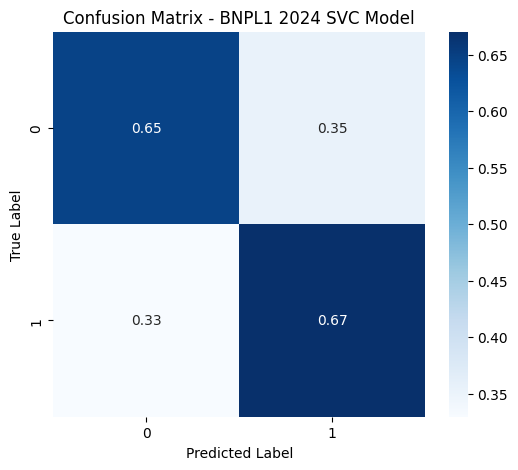

In [139]:
# ---------------------------
# 5. Model results
# ---------------------------

print("CV AUC:", np.mean(auc_scores))
print("F1 Score:", np.mean(f1_scores))

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    sample_weight=weights_all,
    normalize='true'
)

print("Confusion Matrix:", cm)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL1 2024 SVC Model")
plt.show()


## BNPL3 - 2024 data

### Data pre-processing

In [160]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]
data_2024 = data.loc[data['year']==2024]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_11632/2448053278.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [161]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL3']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data_2024[c] = data_2024[c].map(map_cols1)

In [162]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data_2024[c], prefix=c).astype(int)

data_2024 = pd.concat([data_2024, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [163]:
# multi-class to ordinal
cols3 = ['X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

map_cols3 = ({
    'Not a concern': 0,
    'Minor concern': 1,
    'Major concern': 2
})

for c in cols3:
  data_2024[c] = data_2024[c].map(map_cols3)

In [164]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017",'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

scaler = StandardScaler()

data_2024[numeric_cols] = scaler.fit_transform(data_2024[numeric_cols])

In [165]:
data_2024 = data_2024.loc[-data_2024['BNPL3'].isna()]

In [166]:
data_2024.isna().sum()

weight                                                                          0
BNPL1                                                                           0
BNPL3                                                                           0
BNPL4_a                                                                         0
BNPL4_b                                                                         0
BNPL4_c                                                                         0
BNPL4_d                                                                         0
BNPL4_e                                                                         0
BNPL4_f                                                                         0
EF3_a                                                                           0
EF3_b                                                                           0
EF3_c                                                                           0
EF3_d           

In [167]:
# drop columns
data2024_cleaned = data_2024.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                      'I41_e', 'SL6', 'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C'])

In [168]:
data2024_cleaned.isna().sum()

weight                                                                         0
BNPL3                                                                          0
EF3_a                                                                          0
EF3_b                                                                          0
EF3_c                                                                          0
EF3_d                                                                          0
EF3_e                                                                          0
EF3_f                                                                          0
EF3_g                                                                          0
EF3_h                                                                          0
ppage                                                                          0
ppgender                                                                       0
pphhsize                    

In [169]:
data2024_cleaned = data2024_cleaned.dropna()

comment: note this is a small sample with 455 records after removing na rows

### Feature selection

In [170]:
# independent variables
X = data2024_cleaned.drop(columns=['BNPL3','weight'])
# target variable
y = data2024_cleaned['BNPL3']

# weights
weights = data2024_cleaned['weight']


In [171]:
from imblearn.pipeline import Pipeline

BNPL3_2024_svc_model = LinearSVC(max_iter=2000)

rfecv = RFECV(
    estimator=BNPL3_2024_svc_model,
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="f1"
)

# pipeline: resampling happens BEFORE RFECV in each fold
pipeline = Pipeline(steps=[
    ("resample", RandomOverSampler(random_state=42)),
    ("feature_selection", rfecv)
])

# Fit pipeline
pipeline.fit(X, y)

,steps,"[('resample', ...), ('feature_selection', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,shrinkage,None
,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearSVC(max_iter=2000)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)


In [172]:
# get selected features
rfecv = pipeline.named_steps["feature_selection"]
mask = rfecv.support_
selected_features_BNPL3_2024 = X.columns[mask]
print(selected_features_BNPL3_2024)

Index(['EF3_c', 'I41_c', 'A1_a', 'A1_c', 'EF5C', 'I20_Less than your income',
       'I20_More than your income', 'ppfs0596_$250,000 - $499,999',
       'ppfs0596_$50,000 - $99,999', 'ppfs0596_$500,000 - $999,999',
       'ppethm_Hispanic', 'ppethm_Other, Non-Hispanic',
       'ppethm_White, Non-Hispanic', 'ppinc7_$150,000 or more',
       'ppinc7_$75,000 to $99,999', 'ppinc7_Less than $10,000',
       'ppemploy_Working full-time', 'ppemploy_Working part-time',
       'ppmarit5_Never married', 'ppmarit5_Separated', 'ppagecat_35-44',
       'ppagecat_65-74', 'ppfs1482_Don’t know', 'ppfs1482_Good',
       'ppfs1482_Poor', 'B3_Much worse off', 'B3_Somewhat better off',
       'A6_Don’t know', 'C4A_Most or all of the time', 'C4A_Once', 'L0C_3'],
      dtype='str')


### SVC Model

In [173]:
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug = X_aug[selected_features_BNPL3_2024]
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
y_true_all = []
y_pred_all = []
weights_all = []
f1_scores = []

for train_idx, val_idx in skf.split(X_train_aug, y_train):

    X_tr = X_train_aug.iloc[train_idx].copy()
    X_val = X_train_aug.iloc[val_idx].copy()

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Resample ONLY training fold
    ros = RandomOverSampler(random_state=42)
    X_tr_res, y_tr_res = ros.fit_resample(X_tr, y_tr)

    # Extract weights
    w_tr_res = X_tr_res["weight"].values
    X_tr_res = X_tr_res.drop(columns=["weight"])

    w_val = X_val["weight"].values
    X_val = X_val.drop(columns=["weight"])

    # Train model
    model = LinearSVC(
        C=0.1,
        penalty='l1',
        dual=False,
        max_iter=5000
    )

    model.fit(X_tr_res, y_tr_res, sample_weight=w_tr_res)
    y_pred = model.predict(X_val)

    # ---------------------------
    # 4. Evaluation
    # ---------------------------

    # AUC
    y_scores = model.decision_function(X_val)
    auc = roc_auc_score(y_val, y_pred)
    auc_scores.append(auc)

    # F1
    f1 = f1_score(y_val, y_pred)
    f1_scores.append(f1)

    # Confusion matrix metrics
    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred)
    weights_all.extend(w_val)


Evaluation results

CV AUC: 0.7439550072568941
F1 Score: 0.6162122027105416
Confusion Matrix: [[0.74539089 0.25460911]
 [0.25450439 0.74549561]]


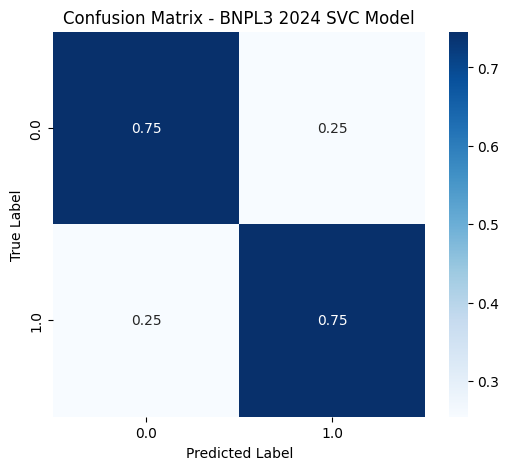

In [174]:
# ---------------------------
# 5. Model results
# ---------------------------

print("CV AUC:", np.mean(auc_scores))
print("F1 Score:", np.mean(f1_scores))

cm = confusion_matrix(
    y_true_all,
    y_pred_all,
    sample_weight=weights_all,
    normalize='true'
)

print("Confusion Matrix:", cm)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL3 2024 SVC Model")
plt.show()
